In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import utils
from clean import load_clean, answer_text

fig_dir = "../report/figs/"

clean_df, X, questions = load_clean()
states = utils.load_states()

In [45]:
eda_questions = ["Q050", "Q105"]

for q in eda_questions:
    answered = clean_df[clean_df[q] > 0][q]
    answer_names = answered.apply(lambda code: answer_text(questions, q, code))
    print(q, questions[q]["question"])
    percents = (answer_names.value_counts(normalize=True) * 100).round(1).rename("percent")
    print(percents)

Q050 What word(s) do you use to address a group of two or more people?
Q050
you guys       42.0
you            23.5
y'all          17.5
you all        12.6
other           3.1
yous, youse     0.6
yins            0.3
you 'uns        0.2
you lot         0.2
Name: percent, dtype: float64
Q105 What is your generic term for a sweetened carbonated beverage?
Q105
soda           47.6
pop            28.6
coke           14.2
soft drink      5.7
other           2.7
tonic           0.7
cocola          0.3
fizzy drink     0.1
dope            0.1
lemonade        0.0
Name: percent, dtype: float64


### Plot on map

In [46]:
def map_top_answer(clean_df, questions, question, states, min_respondents=5):
    answered = clean_df[clean_df[question] > 0]
    names = {code: answer_text(questions, question, code)
             for code in range(1, len(questions[question]["answers"]) + 1)}
    fig, axes = utils.map_top_label(answered, answered[question], names, states, min_respondents)
    axes["contiguous"].set_title(f"{questions[question]['question']}", fontsize=16)
    return fig, axes

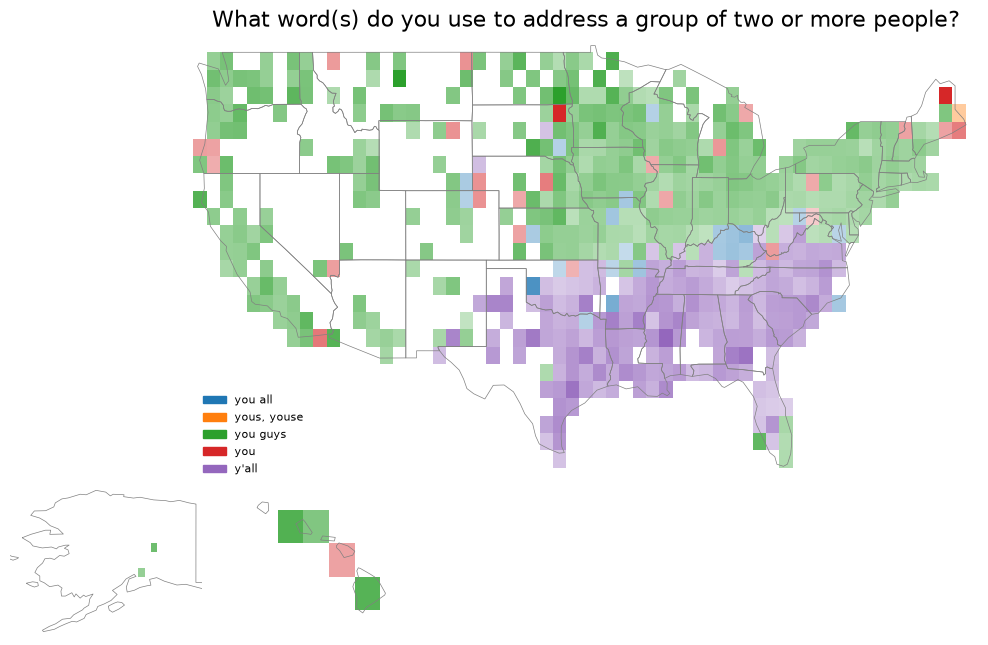

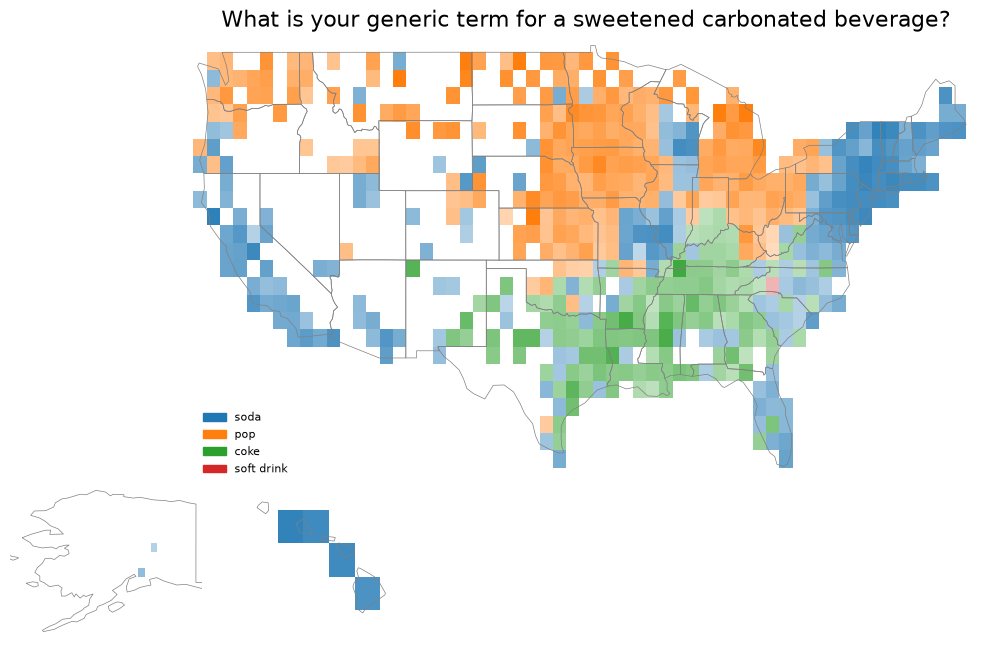

In [47]:
for q in eda_questions:
    fig, axes = map_top_answer(clean_df, questions, q, states)
    fig.savefig(fig_dir + "eda-top-answer-" + q + ".png", dpi=150, bbox_inches="tight")
    plt.show()

The plot shows what the top answer is within each 1 * 1 degree coordinate bins. Bins with less than 5 respondent answers were dropped.

Top answers to Q050 seem to show a pretty clear geographical split between the South (y'all) and the North + West (you guys). A similar, but more divided patterns is shown with top answers to Q105 with a East+West Coast (soda), South (coke), and Midwest (pop) split.

### Does Q050 predict Q105 for one person?

We can test this by learning the most common Q105 answer for each Q050 answer on a random half, then checking on the other half against always guessing the most common answer.

In [52]:
# people who answered both questions, split in half at random
both = clean_df[(clean_df["Q050"] > 0) & (clean_df["Q105"] > 0)]
rng = np.random.default_rng(215)
in_train = rng.random(len(both)) < 0.5
train, test = both[in_train], both[~in_train]
print(len(train), "training people,", len(test), "test people")

def most_common(answers):
    return answers.mode()[0]

# most common Q105 answer for each Q050 answer, learned on the training half
lookup = train.groupby("Q050")["Q105"].agg(most_common)
baseline_answer = most_common(train["Q105"])

predicted = test["Q050"].map(lookup)
lookup_accuracy = (test["Q105"] == predicted).mean() * 100
baseline_accuracy = (test["Q105"] == baseline_answer).mean() * 100

print(f"lookup from Q050: {lookup_accuracy:.1f}% correct")
print(f"always '{answer_text(questions, 'Q105', baseline_answer)}': {baseline_accuracy:.1f}% correct")

22454 training people, 22478 test people
lookup from Q050: 49.9% correct
always 'soda': 47.3% correct


In [ ]:
correct_lookup = test["Q105"] == predicted
correct_baseline = test["Q105"] == baseline_answer
by_group = pd.DataFrame({
    "n (test)": test.groupby("Q050").size(),
    "predicted Q105": lookup.map(lambda code: answer_text(questions, "Q105", code)),
    "% correct (lookup)": correct_lookup.groupby(test["Q050"]).mean() * 100,
    "% correct (baseline)": correct_baseline.groupby(test["Q050"]).mean() * 100,
})
by_group.index = [answer_text(questions, "Q050", code) for code in by_group.index]
by_group.sort_values("n (test)", ascending=False).round(1)

,n (test),predicted Q105,% correct (lookup),% correct (baseline)
you guys,9340,soda,49.1,49.1
you,5278,soda,55.6,55.6
y'all,3945,coke,45.0,31.9
you all,2900,soda,47.6,47.6
other,717,soda,48.1,48.1
"yous, youse",156,soda,67.3,67.3
yins,63,pop,79.4,19.0
you 'uns,45,pop,62.2,11.1
you lot,34,soda,44.1,44.1
